In [4]:
import numpy as np
import os
from scipy import stats
from numpy import genfromtxt
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
a = 0.5
x = [a**i for i in range(1,100)]
y = [i for i in range(1,100)]

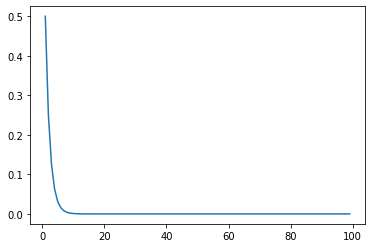

In [10]:
plt.plot(y,x)

In [20]:
body_acc_x = genfromtxt('train/body_acc_x_train.csv', delimiter=',')
body_acc_y = genfromtxt('train/body_acc_y_train.csv',delimiter = ',')
body_acc_z = genfromtxt('train/body_acc_z_train.csv',delimiter = ',')
body_gyro_x = genfromtxt('train/body_gyro_x_train.csv',delimiter = ',')
body_gyro_y = genfromtxt('train/body_gyro_y_train.csv',delimiter = ',')
body_gyro_z = genfromtxt('train/body_gyro_y_train.csv',delimiter = ',')
total_acc_x = genfromtxt('train/total_acc_x_train.csv',delimiter = ',')
total_acc_y = genfromtxt('train/total_acc_y_train.csv',delimiter = ',')
total_acc_z = genfromtxt('train/total_acc_z_train.csv',delimiter = ',')

In [65]:
data = np.hstack((body_acc_x,body_acc_y))
data = np.hstack((data,body_acc_z))
data = np.hstack((data,body_gyro_x))
data = np.hstack((data,body_gyro_y))
data = np.hstack((data,body_gyro_z))
data = np.hstack((data,total_acc_x))
data = np.hstack((data,total_acc_y))
data = np.hstack((data,total_acc_z))

In [76]:
data.shape

(10299, 1153)

In [67]:
y_train = genfromtxt('train/y_train.csv',delimiter = ',')

In [73]:
data = genfromtxt('train/1_train.csv', delimiter=',')  

In [63]:
data[0,0]

0.1153654

In [75]:
data = genfromtxt('data.csv', delimiter=',')
batch_size = 16

In [33]:
x_batch = X[0:16,:,:,:]

In [31]:
X = np.transpose(X,(0,3,1,2))

In [8]:
x = data[:,:-1]
y = data[:,-1]

In [35]:
y.shape

(10299,)

In [52]:
y = y -1 
y = np.reshape(y,(-1,1)).astype(int)
zeros = np.zeros((len(y),6))
for i,c in enumerate(y):
    zeros[i,c] = 1
    

In [53]:
zeros[0,:]

array([0., 0., 1., 0., 0., 0.])

In [70]:
def windowz(data, size):
    start = 0
    while start < len(data):
        yield start, start + size
#         start += (size // 2)
        start += size        

In [71]:
def save_npy(x,y,mode,batch_size,res_dir):
    for i,(start,end) in enumerate(windowz(x,batch_size)):
        file_name_x = 'x_{}_{}'.format(mode,i)
        file_name_y = 'y_{}_{}'.format(mode,i)
        path_to_x = os.path.join(res_dir,file_name_x)
        path_to_y = os.path.join(res_dir,file_name_y)
        if end < len(x):
            x_batch= x[start:end,:,:,:]
            y_batch= y[start:end,:]
        else:
            x_batch= x[start:,:,:,:]
            y_batch= y[start:,:]
        np.save(path_to_x,x_batch) 
        np.save(path_to_y,y_batch)

In [13]:
d = np.zeros((100,1))
size = 16

In [44]:
for i, (start, end) in enumerate(windowz(d,size)):
    print('i:{},s:{},e:{}'.format(i,start,end))

i:0,s:0,e:16
i:1,s:16,e:32
i:2,s:32,e:48
i:3,s:48,e:64
i:4,s:64,e:80
i:5,s:80,e:96
i:6,s:96,e:112


In [72]:
def gen_npy(data,channel,height,width,num_classes,batch_size=16):
    parent_dir = os.path.dirname(os.getcwd())
    res_dir = os.path.join(parent_dir,'NPY_data/')
    if not os.path.exists(res_dir):
        os.makedirs(res_dir)
    X = data[:,:-1]
    X = np.reshape(X,(-1,height,width,channel))
    X = np.transpose(X,(0,3,1,2))
    y = data[:,-1] -1 
    y = np.reshape(y,(-1,1)).astype(int)
    zeros = np.zeros((len(y),num_classes))
    for i,c in enumerate(y):
        zeros[i,c] = 1
    y = zeros    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train = (X_train - np.mean(X_train))/np.std(X_train)
    X_test = (X_test - np.mean(X_test))/np.std(X_test)
    # save x_train,y_train
    save_npy(X_train,y_train,mode='train',batch_size=batch_size,res_dir=res_dir)
    save_npy(X_test,y_test,mode='test',batch_size=batch_size,res_dir=res_dir)
    
#     for i,(start,end) in enumerate(windowz(X_train,batch_size)):
#         file_name_x = 'x_train_{}'.format(i)
#         file_name_y = 'y_train_()'.format(i)
#         path_to_x = os.join(res_dir,file_name_x)
#         path_to_y = os.join(res_dir,file_name_y)
#         if end < len(X_train):
#             x_batch= X_train[start:end,:,:,:]
#             y_batch= y_train[start:end,:]
#         else:
#             x_batch= X_train[start:,:,:,:]
#             y_batch= y_train[start:,:]
#         np.save(path_to_x,x_batch) 
#         np.save(path_to_y,y_batch)

In [77]:
gen_npy(data=data,channel=9,height=1,width=128,num_classes=6,batch_size=16)

In [16]:
data = genfromtxt('x_train.csv', delimiter=',')

In [17]:
data.shape

(7352, 1153)

In [7]:
np.unique(data[:,-1],return_counts=True)

(array([1., 2., 3., 4., 5., 6.]), array([1722, 1544, 1406, 1777, 1906, 1944]))

In [13]:
np.random.shuffle(data)

In [21]:
count = {
    "1": 0,
    "2": 0,
    "3": 0,
    "4": 0,
    "5": 0,
    "6": 0,
}

test_balance = np.zeros((300,1153))
cnt = 0;
for line in data:
    if count[str(int(line[-1]))] <50:
        test_balance[cnt,:] = line
        count[str(int(line[-1]))]=  count[str(int(line[-1]))]+1
        cnt += 1
        line[-1] = 0

In [19]:
data = test_balance 

In [20]:
np.unique(data[:,-1],return_counts=True)

(array([1., 2., 3., 4., 5., 6.]), array([400, 400, 400, 400, 400, 400]))

In [22]:
f_train = data[np.where( (data[:,-1]!=0))]

In [23]:
f_test = test_balance

In [24]:
np.unique(f_test[:,-1],return_counts=True)

(array([1., 2., 3., 4., 5., 6.]), array([50, 50, 50, 50, 50, 50]))

In [25]:
np.unique(f_train[:,-1],return_counts=True)

(array([1., 2., 3., 4., 5., 6.]), array([350, 350, 350, 350, 350, 350]))

In [26]:
np.savetxt("/Users/zber/Desktop/1_Data/Har/demo_test.csv",f_test, delimiter=',',fmt='%1.10e') 

In [27]:
np.savetxt("/Users/zber/Desktop/1_Data/Har/demo_train.csv",f_train, delimiter=',',fmt='%1.10e') 

In [28]:
f_train.shape,f_test.shape

((2100, 1153), (300, 1153))